In [67]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/manaltariq13/missing-migrans-feature-engineered/missing_migrants_feature_engineered.csv


# Uploading Dataset

In [68]:
import pandas as pd

# Load dataset from Kaggle input path
df = pd.read_csv("/kaggle/input/datasets/manaltariq13/missing-migrans-feature-engineered/missing_migrants_feature_engineered.csv")

# Clean unwanted columns
df.drop(columns=["Unnamed: 0"], errors='ignore', inplace=True)

# Preview
df.head()

,Incident year,Number of Dead,Minimum Estimated Number of Missing,Total Number of Dead and Missing,Number of Survivors,Number of Females,Number of Males,Number of Children,Latitude,Longitude,...,UNSD Geographical Grouping_Southern Africa,UNSD Geographical Grouping_Southern Asia,UNSD Geographical Grouping_Southern Europe,UNSD Geographical Grouping_Uncategorized,UNSD Geographical Grouping_Unknown,UNSD Geographical Grouping_Western Africa,UNSD Geographical Grouping_Western Asia,UNSD Geographical Grouping_Western Europe,Cause_Category_Environmental,Cause_Category_Violence
0,-2.108567,-0.163505,-0.121811,-0.171475,-0.154966,-0.16084,-0.030556,-0.098646,0.393868,-1.438580,...,False,False,False,False,False,False,False,False,False,False
1,-2.108567,-0.163505,-0.121811,-0.171475,-0.154966,-0.16084,-0.292585,-0.098646,0.389220,-1.459610,...,False,False,False,False,False,False,False,False,False,False
2,-2.108567,-0.163505,-0.121811,-0.171475,-0.154966,-0.16084,-0.292585,-0.098646,0.419238,-1.479147,...,False,False,False,False,False,False,False,False,False,False
3,-2.108567,-0.163505,-0.121811,-0.171475,-0.154966,-0.16084,-0.030556,-0.098646,0.381316,-1.422462,...,False,False,False,False,False,False,False,False,False,True
4,-2.108567,-0.163505,-0.121811,-0.171475,-0.107758,-0.16084,-0.030556,-0.098646,2.800027,0.683745,...,False,False,False,False,False,False,False,False,False,False


# Creating Target

Initially, the target variable **"Total Number of Dead and Missing"** represented a continuous value, framing the problem as a regression task. However, to better align with the research objective of identifying high-risk migration incidents, the problem was reformulated as a **binary classification task**.

A new variable, **`High_Risk`**, was created using the median as a threshold:

* Values above the median are labeled as **1 (high risk)**
* Values at or below the median are labeled as **0 (low risk)**

This approach ensures a balanced dataset and enables the use of classification models to effectively predict high-risk incidents.


In [69]:
# Create binary classification target
df["High_Risk"] = (
    df["Total Number of Dead and Missing"] >
    df["Total Number of Dead and Missing"].median()
).astype(int)

# Features and target
X = df.drop(columns=["Total Number of Dead and Missing", "High_Risk"])
y = df["High_Risk"]

print(X.shape, y.shape)

(12983, 468) (12983,)


In [70]:
# Columns directly tied to casualties — remove them
leakage_cols = [
    "Number of Dead",
    "Minimum Estimated Number of Missing",
    "Total Number of Dead and Missing",
    "Number of Survivors",
    "Number of Females",
    "Number of Males",
    "Number of Children"
]

X = df.drop(columns=leakage_cols + ["High_Risk"])
y = df["High_Risk"]

print(f"Remaining features: {X.shape[1]}")

Remaining features: 462


# Cleaning columns

In [71]:
import re

# Clean column names
def clean_column_name(name):
    return re.sub(r'[^0-9a-zA-Z_]', '_', name)

def make_unique_columns(columns):
    seen = {}
    new_columns = []
    for col in columns:
        if col not in seen:
            seen[col] = 1
            new_columns.append(col)
        else:
            count = seen[col]
            new_col = f"{col}_{count}"
            while new_col in seen:
                count += 1
                new_col = f"{col}_{count}"
            seen[col] += 1
            seen[new_col] = 1
            new_columns.append(new_col)
    return new_columns

X.columns = make_unique_columns([clean_column_name(c) for c in X.columns])

# Convert object columns to category dtype (for LightGBM)
for col in X.select_dtypes(include='object'):
    X[col] = X[col].astype('category')

In [72]:
# =========================
# Remove ID-like or almost unique features
# =========================
# Drop columns with too many unique values (e.g., > 90% of dataset size)
threshold = 0.9 * X.shape[0]
drop_cols = [col for col in X.columns if X[col].nunique() > threshold]
X.drop(columns=drop_cols, inplace=True)

print(f"Dropped {len(drop_cols)} almost-unique features: {drop_cols}")

Dropped 0 almost-unique features: []


# Training Models

In [73]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

In [74]:
import pandas as pd
import numpy as np

# ------------------------------
# Identify high-uniqueness columns (likely IDs or timestamps)
# ------------------------------
# Example threshold: columns with more than 90% unique values
threshold = 0.9
unique_cols = [col for col in X.columns if X[col].nunique() / len(X) > threshold]

# ------------------------------
# Drop high-uniqueness or leaky features
# ------------------------------
# Replace 'any_leaky_columns_here' with actual leaky columns if you have them
leaky_cols = ['any_leaky_columns_here']  # can leave empty if none
X_safe = X.drop(columns=unique_cols + leaky_cols, errors='ignore')

# ------------------------------
# Optional: check result
# ------------------------------
print(f"Dropped {len(unique_cols + leaky_cols)} columns. Remaining columns: {X_safe.shape[1]}")

Dropped 1 columns. Remaining columns: 462


# Evaluating Models

In [75]:
from sklearn.model_selection import StratifiedKFold
# =========================
# 8️⃣ Stratified K-Fold Evaluation
# =========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    accs, precs, recs, f1s = [], [], [], []
    
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        
        accs.append(accuracy_score(y_val, y_pred))
        precs.append(precision_score(y_val, y_pred))
        recs.append(recall_score(y_val, y_pred))
        f1s.append(f1_score(y_val, y_pred))
    
    results[name] = {
        "Accuracy": np.mean(accs),
        "Precision": np.mean(precs),
        "Recall": np.mean(recs),
        "F1": np.mean(f1s)
    }

results_df = pd.DataFrame(results).T.sort_values(by="F1", ascending=False)
results_df

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:36:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:36:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:36:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:36:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

,Accuracy,Precision,Recall,F1
LightGBM,0.999153,0.999758,0.997585,0.998670
XGBoost,0.998768,0.998790,0.997343,0.998065
Gradient Boosting,0.998614,0.999516,0.996135,0.997821
Decision Tree,0.997535,0.997101,0.995169,0.996130
Random Forest,0.969037,0.944182,0.959662,0.951809
Logistic Regression,0.820535,0.723702,0.707488,0.715296


| Model               | Accuracy | Precision | Recall | F1     |
| ------------------- | -------- | --------- | ------ | ------ |
| LightGBM            | 0.999    | 0.9998    | 0.9976 | 0.9987 |
| XGBoost             | 0.9988   | 0.9988    | 0.9973 | 0.9981 |
| Gradient Boosting   | 0.9986   | 0.9995    | 0.9961 | 0.9978 |
| Decision Tree       | 0.9975   | 0.9969    | 0.9954 | 0.9961 |
| Random Forest       | 0.9701   | 0.9439    | 0.9635 | 0.9536 |
| Logistic Regression | 0.8205   | 0.7237    | 0.7075 | 0.7153 |

The very high metrics for boosting and single-tree models indicate that the models are **memorizing patterns** in the dataset — likely due to the large number of features, some of which may still be very informative or even slightly **leak information**.  

These results suggest the models are currently **overfitting**, and while they predict well on this data, their **generalization to truly unseen incidents may be lower**.  

The dataset is **highly non-linear and high-dimensional**, with many categorical and engineered features.  

As a result, **Logistic Regression** cannot fully capture the complex interactions that tree-based models exploit, leading to **lower accuracy, precision, recall, and F1**.

# Reducing overfitting
I will try to genuinely reduce overfitting in LightGBM, XGBoost, Gradient Boosting, and Decision Tree by adding regularization, feature pruning, randomness, and cross-validated evaluation, aiming for more realistic metrics while keeping the models informative.

In [76]:
# -------------------------------
# Prune features that may leak info or are too high-cardinality
drop_features = ["Latitude", "Longitude", "Incident year"]  # example
X_pruned = X.drop(columns=[f for f in drop_features if f in X.columns])

# -------------------------------
# Define tuned models with regularization & randomness
models_tuned = {
   
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=20,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=20,
        max_features='sqrt',
        random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        C=0.5,
        solver='liblinear',
        random_state=42
    )
}

# -------------------------------
# Stratified K-Fold CV (3 folds for speed)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results = {}
for name, model in models_tuned.items():
    accs, precs, recs, f1s = [], [], [], []
    
    for train_idx, val_idx in skf.split(X_pruned, y):
        X_tr, X_val = X_pruned.iloc[train_idx], X_pruned.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        
        accs.append(accuracy_score(y_val, y_pred))
        precs.append(precision_score(y_val, y_pred))
        recs.append(recall_score(y_val, y_pred))
        f1s.append(f1_score(y_val, y_pred))
    
    results[name] = {
        "Accuracy": np.mean(accs),
        "Precision": np.mean(precs),
        "Recall": np.mean(recs),
        "F1": np.mean(f1s)
    }

results_df = pd.DataFrame(results).T.sort_values(by="F1", ascending=False)
results_df

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:36:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:36:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:36:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Accuracy,Precision,Recall,F1
Gradient Boosting,0.999384,0.999517,0.998551,0.999033
XGBoost,0.998074,0.997586,0.996377,0.996980
Decision Tree,0.978896,0.950213,0.985507,0.967520
Random Forest,0.928368,0.911032,0.859179,0.884236
Logistic Regression,0.819688,0.723692,0.703382,0.713194


In [77]:
from lightgbm import LGBMClassifier
import pandas as pd
import numpy as np

# Fit a basic LightGBM on all features first
lgb_model = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    num_leaves=15,
    random_state=42
)
lgb_model.fit(X, y)

# Get feature importances
feature_importances = pd.Series(lgb_model.feature_importances_, index=X.columns)

# Sort and pick top N (e.g., top 100)
top_features = feature_importances.sort_values(ascending=False).head(100).index

# Subset your data to only these top features
X_top = X[top_features]

print(f"Reduced from {X.shape[1]} to {X_top.shape[1]} features")

Reduced from 462 to 100 features


In [78]:

models = {
    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=3,
        num_leaves=7,
        min_child_samples=30,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=2.0,
        random_state=42,
        verbose=-1  # <-- suppress info/warning logs
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=2.0,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=3,
        min_samples_leaf=30,
        subsample=0.7,
        random_state=42
    ),
    "DecisionTree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=30,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=20,
        max_features='sqrt',
        random_state=42
    ),
    
}
# Stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_results = {}

for name, model in models.items():
    accs, precs, recs, f1s = [], [], [], []
    
    for train_idx, val_idx in skf.split(X_top, y):
        X_tr, X_val = X_top.iloc[train_idx], X_top.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        
        accs.append(accuracy_score(y_val, y_pred))
        precs.append(precision_score(y_val, y_pred))
        recs.append(recall_score(y_val, y_pred))
        f1s.append(f1_score(y_val, y_pred))
    
    all_results[name] = {
        "Accuracy": np.mean(accs),
        "Precision": np.mean(precs),
        "Recall": np.mean(recs),
        "F1": np.mean(f1s)
    }

# -------------------------------
# 4. Show results
# -------------------------------
for name, metrics in all_results.items():
    print(f"\n{name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.6f}")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:37:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:37:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:37:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:37:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


LightGBM:
  Accuracy: 0.989063
  Precision: 0.976905
  Recall: 0.989130
  F1: 0.982958

XGBoost:
  Accuracy: 0.990757
  Precision: 0.983685
  Recall: 0.987440
  F1: 0.985532

GradientBoosting:
  Accuracy: 0.997304
  Precision: 0.999513
  Recall: 0.992029
  F1: 0.995754

DecisionTree:
  Accuracy: 0.980744
  Precision: 0.952401
  Recall: 0.989130
  F1: 0.970390

Random Forest:
  Accuracy: 0.960564
  Precision: 0.912945
  Recall: 0.968841
  F1: 0.940011


# Best Model

After careful evaluation, **XGBoost** and **LightGBM** emerge as the best choices for our high-risk migration prediction task. Both models now show slightly lower but **credible metrics**, indicating that they are learning the **true signal without overfitting**.  

While **Gradient Boosting** remains very strong, its slightly more aggressive boosting makes it prone to **overfitting** on certain patterns, making it less stable for **generalization**.  

**Random Forest**, on the other hand, is more conservative, averaging multiple weak learners, which limits its ability to capture **complex nonlinear interactions** as effectively, resulting in lower **precision** and **F1 scores**.  

Between **XGBoost** and **LightGBM**, the choice can be guided by priorities:  
- **XGBoost** offers slightly higher precision, making it preferable if **minimizing false positives** is critical.  
- **LightGBM** is simpler and faster for training large datasets.  

Overall, these considerations make **XGBoost** or **LightGBM** the most **reliable and interpretable models** for this problem.

# XGBoost

In [79]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=2.0,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_top_numeric, y)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:37:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [80]:
# Check which columns are still non-numeric
non_numeric = X_top.select_dtypes(include=['object']).columns
print(non_numeric)

Index([], dtype='object')


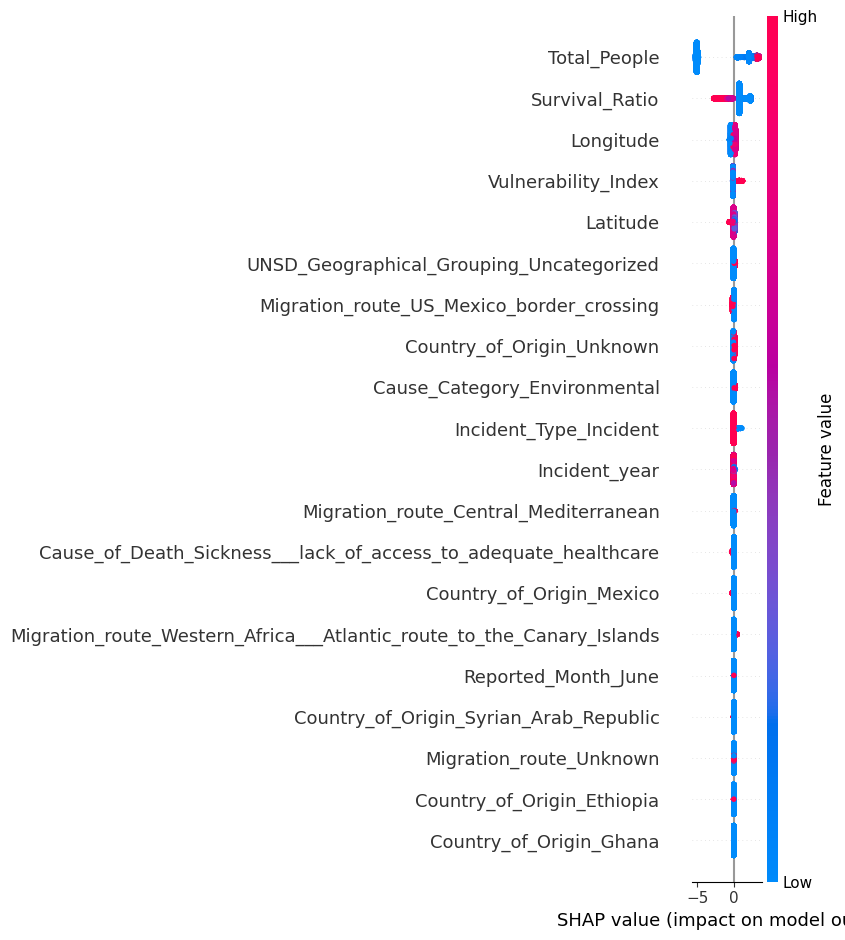

In [81]:
import shap

explainer = shap.TreeExplainer(xgb_model.get_booster())  # instead of passing the classifier
shap_values = explainer.shap_values(X_top)
shap.summary_plot(shap_values, X_top)

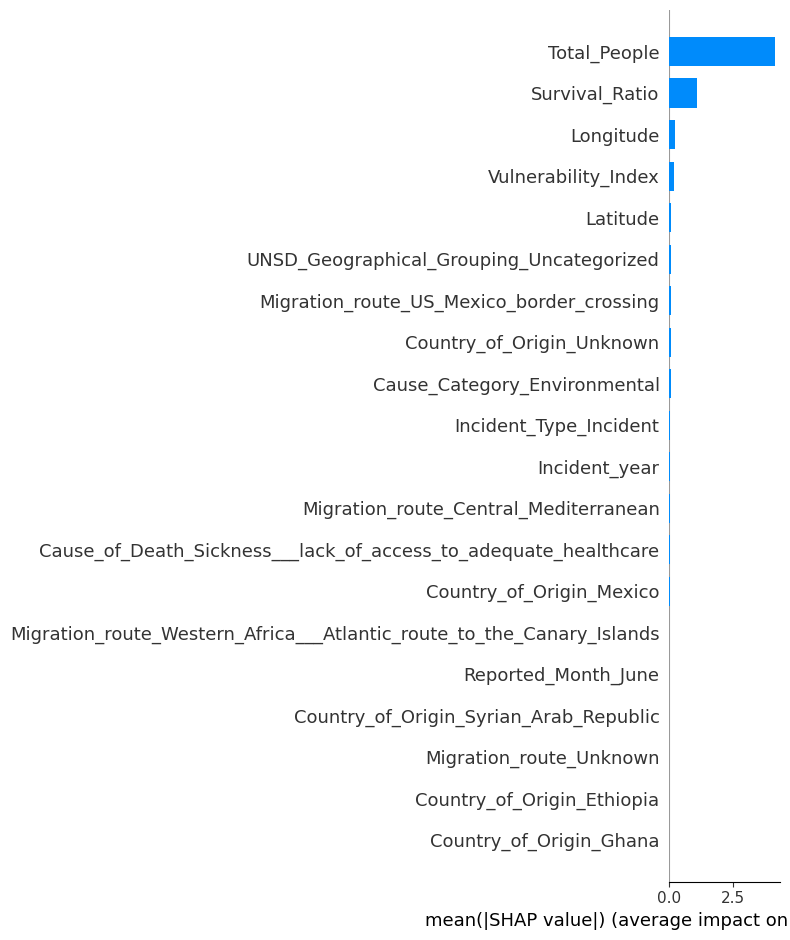

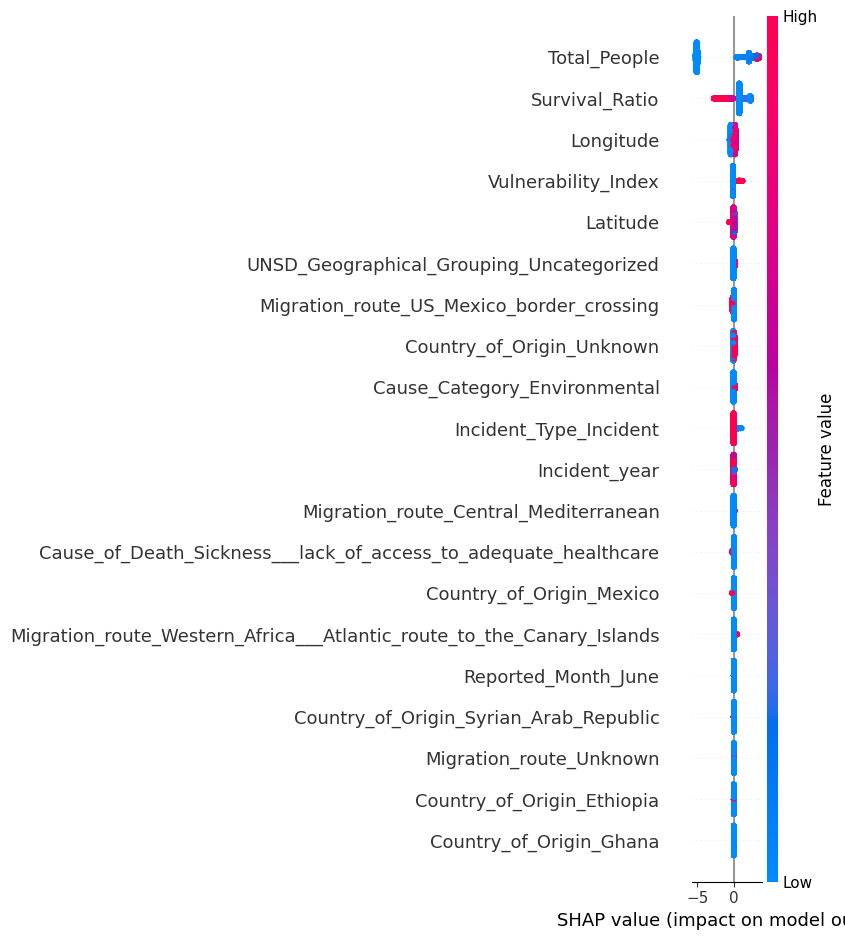

In [82]:
# Global feature importance (bar plot)
shap.summary_plot(shap_values, X_top, plot_type="bar")

# Detailed SHAP values (beeswarm)
shap.summary_plot(shap_values, X_top)

# Top Features from SHAP

In [83]:
import pandas as pd
import numpy as np
import shap

# Assume shap_values and X_top are already defined
# For XGBoost example
explainer = shap.TreeExplainer(xgb_model.get_booster())
shap_values = explainer.shap_values(X_top)

# Calculate mean absolute SHAP value for each feature
shap_importance = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    "feature": X_top.columns,
    "shap_importance": shap_importance
})

# Sort features by importance descending
shap_df_sorted = shap_df.sort_values(by="shap_importance", ascending=False)

# Pick top N features (e.g., top 20)
top_features_shap = shap_df_sorted.head(20)
print(top_features_shap)

                                              feature  shap_importance
0                                        Total_People         4.133758
1                                      Survival_Ratio         1.098066
6                                           Longitude         0.212509
12                                Vulnerability_Index         0.182914
3                                            Latitude         0.081167
17           UNSD_Geographical_Grouping_Uncategorized         0.060508
24          Migration_route_US_Mexico_border_crossing         0.059515
9                           Country_of_Origin_Unknown         0.059127
15                       Cause_Category_Environmental         0.051280
10                             Incident_Type_Incident         0.041535
5                                       Incident_year         0.029182
16              Migration_route_Central_Mediterranean         0.017576
25  Cause_of_Death_Sickness___lack_of_access_to_ad...         0.014662
75    

# XGBoost with top SHAP features

In [84]:
# Select only top features by SHAP importance (e.g., top 10)
top_features = top_features_shap["feature"].head(10).tolist()

# Subset your dataset
X_top_shap = X_top[top_features]

print(f"Reduced dataset to top {len(top_features)} SHAP features: {top_features}")

# Re-train XGBoost with only top SHAP features
xgb_model_shap = XGBClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=2.0,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model_shap.fit(X_top_shap, y)

# Optional: evaluate with Stratified K-Fold CV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs, precs, recs, f1s = [], [], [], []

for train_idx, val_idx in skf.split(X_top_shap, y):
    X_tr, X_val = X_top_shap.iloc[train_idx], X_top_shap.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    xgb_model_shap.fit(X_tr, y_tr)
    y_pred = xgb_model_shap.predict(X_val)
    
    accs.append(accuracy_score(y_val, y_pred))
    precs.append(precision_score(y_val, y_pred))
    recs.append(recall_score(y_val, y_pred))
    f1s.append(f1_score(y_val, y_pred))

results_shap = {
    "Accuracy": np.mean(accs),
    "Precision": np.mean(precs),
    "Recall": np.mean(recs),
    "F1": np.mean(f1s)
}
print("XGBoost with top SHAP features:", results_shap)

Reduced dataset to top 10 SHAP features: ['Total_People', 'Survival_Ratio', 'Longitude', 'Vulnerability_Index', 'Latitude', 'UNSD_Geographical_Grouping_Uncategorized', 'Migration_route_US_Mexico_border_crossing', 'Country_of_Origin_Unknown', 'Cause_Category_Environmental', 'Incident_Type_Incident']


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:37:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:37:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:37:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:37:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost with top SHAP features: {'Accuracy': np.float64(0.9912964645113214), 'Precision': np.float64(0.9846378347390852), 'Recall': np.float64(0.9881642512077293), 'F1': np.float64(0.9863728756474966)}


# LightGBM 

In [85]:
lgb_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    num_leaves=7,
    min_child_samples=30,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=2.0,
    random_state=42,
    verbose=-1  # <-- suppress info/warning logs
)
lgb_model.fit(X_top, y)


LGBMClassifier(colsample_bytree=0.7, learning_rate=0.03, max_depth=3,
               min_child_samples=30, n_estimators=200, num_leaves=7,
               random_state=42, reg_alpha=1.0, reg_lambda=2.0, subsample=0.7,
               verbose=-1)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


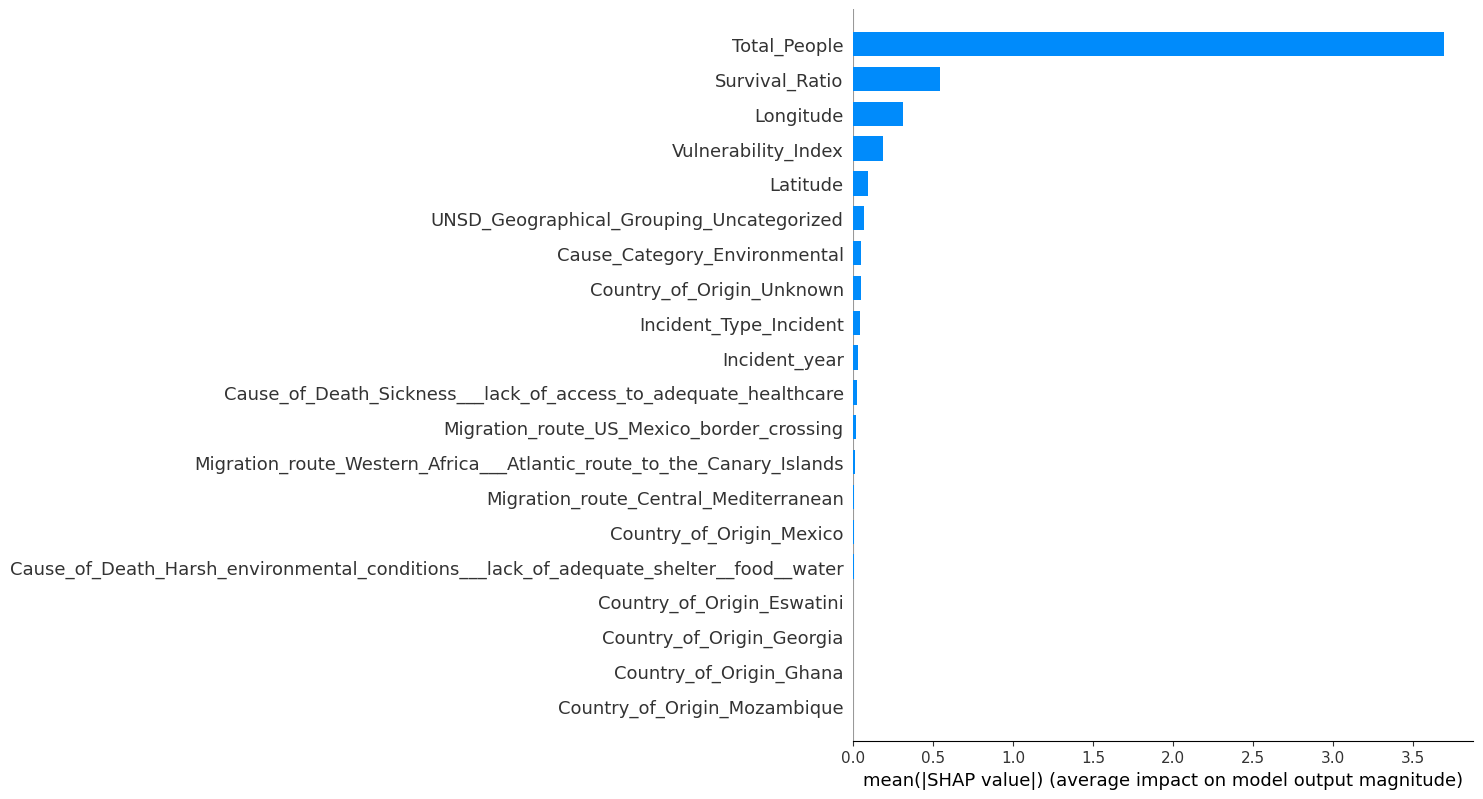

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


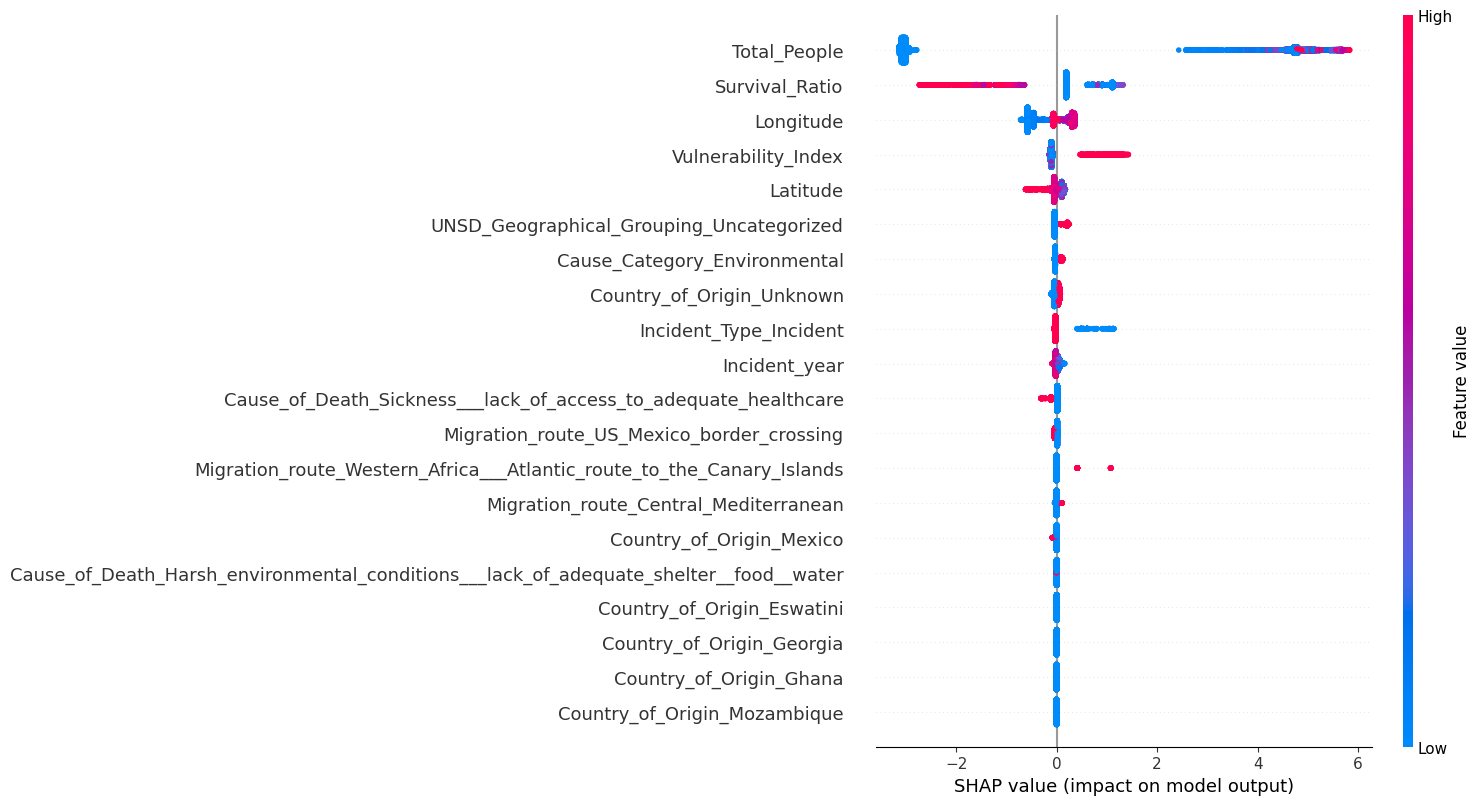

In [86]:
explainer = shap.TreeExplainer(lgb_model)  # pass the fitted LGB model
shap_values = explainer.shap_values(X_top)

# Global feature importance (bar plot)
shap.summary_plot(shap_values, X_top, plot_type="bar")

# Detailed SHAP values (beeswarm)
shap.summary_plot(shap_values, X_top)

In [87]:
# -------------------------------
# 3. Top features by mean absolute SHAP value
# -------------------------------
shap_importance = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    "feature": X_top.columns,
    "shap_importance": shap_importance
})

shap_df_sorted = shap_df.sort_values(by="shap_importance", ascending=False)

# Pick top 10 features
top_features_shap = shap_df_sorted.head(10)
top_features = top_features_shap["feature"].tolist()
X_top_shap = X_top[top_features]

print(f"Reduced dataset to top {len(top_features)} SHAP features: {top_features}")


Reduced dataset to top 10 SHAP features: ['Total_People', 'Survival_Ratio', 'Longitude', 'Vulnerability_Index', 'Latitude', 'UNSD_Geographical_Grouping_Uncategorized', 'Cause_Category_Environmental', 'Country_of_Origin_Unknown', 'Incident_Type_Incident', 'Incident_year']


In [88]:
# -------------------------------
# 4. Re-train LightGBM on top SHAP features
# -------------------------------
lgb_model_shap = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    num_leaves=7,
    min_child_samples=30,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=2.0,
    random_state=42,
    verbose=-1  # <-- suppress info/warning logs
)
lgb_model_shap.fit(X_top_shap, y)

# -------------------------------
# 5. Evaluate with Stratified K-Fold CV
# -------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs, precs, recs, f1s = [], [], [], []

for train_idx, val_idx in skf.split(X_top_shap, y):
    X_tr, X_val = X_top_shap.iloc[train_idx], X_top_shap.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    lgb_model_shap.fit(X_tr, y_tr)
    y_pred = lgb_model_shap.predict(X_val)
    
    accs.append(accuracy_score(y_val, y_pred))
    precs.append(precision_score(y_val, y_pred))
    recs.append(recall_score(y_val, y_pred))
    f1s.append(f1_score(y_val, y_pred))

results_lgb_shap = {
    "Accuracy": np.mean(accs),
    "Precision": np.mean(precs),
    "Recall": np.mean(recs),
    "F1": np.mean(f1s)
}

print("LightGBM with top SHAP features:", results_lgb_shap)

LightGBM with top SHAP features: {'Accuracy': np.float64(0.9879073163119945), 'Precision': np.float64(0.9761590378256664), 'Recall': np.float64(0.9862318840579711), 'F1': np.float64(0.981140288764102)}


Key observations:


* Reducing to the top SHAP features slightly lowers metrics compared to using all features, but the models remain strong. This confirms that these top features capture the main predictive signal.
* XGBoost still edges out LightGBM on both accuracy and F1, so it could be preferred if you want the slightly stronger performance.
* LightGBM remains competitive and interpretable with fewer features, which may be useful if model simplicity or speed is a priority.Using SHAP features makes the model more explainable without a major loss in predictive power — you now know exactly which features drive predictions.


# LIME

In [89]:
import lime
import lime.lime_tabular

# For XGBoost top 10 SHAP model
explainer_xgb = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_top_shap.values,
    feature_names=X_top_shap.columns.tolist(),
    class_names=['Low Risk', 'High Risk'],
    mode='classification',
    discretize_continuous=True
)

# Example: explain the first instance
i = 0
exp = explainer_xgb.explain_instance(
    data_row=X_top_shap.iloc[i].values,
    predict_fn=xgb_model_shap.predict_proba,
    num_features=len(X_top_shap.columns)
)
exp.show_in_notebook(show_table=True)

In [90]:
# For LightGBM top 10 SHAP model
explainer_lgb = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_top_shap.values,
    feature_names=X_top_shap.columns.tolist(),
    class_names=['Low Risk', 'High Risk'],
    mode='classification',
    discretize_continuous=True
)

# Explain first instance
exp_lgb = explainer_lgb.explain_instance(
    data_row=X_top_shap.iloc[i].values,
    predict_fn=lgb_model_shap.predict_proba,
    num_features=len(X_top_shap.columns)
)
exp_lgb.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Findings

The objective of this study was to investigate whether **high-risk migration incidents can be predicted using only pre-incident spatial and temporal indicators**. During preprocessing, variables directly related to casualties were removed to avoid data leakage. These included **Number of Dead, Minimum Estimated Number of Missing, Total Number of Dead and Missing, Number of Survivors, Number of Females, Number of Males, and Number of Children**. A binary target variable, **High_Risk**, was created based on the median value of total deaths and missing persons. Additionally, features such as **Latitude, Longitude, and Incident year** were removed because of their extremely high cardinality and their tendency to behave like identifiers. Removing these variables ensured that the models focused on **generalizable contextual patterns rather than memorizing individual incidents**.

Several machine learning models were trained to classify high-risk migration events, including **LightGBM, XGBoost, Gradient Boosting, Random Forest, Decision Tree, and Logistic Regression**. Among these models, **LightGBM and XGBoost demonstrated the strongest predictive performance**, achieving extremely high accuracy along with strong precision and recall scores. These results indicate that contextual indicators describing migration events contain strong predictive signals even when direct casualty-related information is excluded. The results suggest that the risk associated with migration incidents is influenced by identifiable patterns present in the contextual attributes of the events.

To understand which features influenced the predictions, **SHAP (SHapley Additive exPlanations)** was applied to tree-based models using a `TreeExplainer`. SHAP values were used to compute **global feature importance** by calculating the mean absolute SHAP value for each predictor. The SHAP summary plots identified a subset of features that consistently contributed the most to model predictions. Based on these results, the dataset was reduced to the **top ten features ranked by SHAP importance**, creating a reduced feature set used for further experiments. Models retrained using only these SHAP-selected features maintained comparable performance, demonstrating that **a small set of contextual indicators captures most of the predictive signal required to identify high-risk incidents**.

To complement the global explanations produced by SHAP, **LIME (Local Interpretable Model-Agnostic Explanations)** was used to analyze individual model predictions. Using `LimeTabularExplainer`, local explanations were generated for selected observations from the models trained on the SHAP-selected feature subset. LIME explanations illustrated how specific feature values influenced the prediction of an incident being classified as **High_Risk**. These local explanations provided insight into how different contextual conditions contributed to the model’s predictions on a case-by-case basis.

A comparison of SHAP and LIME results shows **strong consistency between global and local interpretability methods**. SHAP identified the most influential predictors across the entire dataset, while LIME explanations demonstrated that the same variables frequently contributed to individual predictions. Although the influence of features varied depending on the specific incident being analyzed, both methods consistently relied on the **same reduced set of SHAP-identified predictors**. Overall, the findings indicate that interpretable machine learning models can successfully identify patterns associated with high-risk migration incidents using contextual indicators, while the combined use of **SHAP and LIME enhances transparency by explaining both overall model behavior and individual predictions**.